# Toxicity Prediction Using Chemical Descriptors
## Complete Analysis Pipeline: EDA, Feature Selection, Model Training & Evaluation

In [4]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Create outputs directory
import os
if not os.path.exists('outputs'):
    os.makedirs('outputs')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [7]:
# Load the dataset - going up one folder
print("="*60)
print("STEP 1: LOADING DATA")
print("="*60)

import os

# Current directory is 'outputs', so go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)  # Go up one folder
data_path = os.path.join(parent_dir, 'data.csv')

print(f"Looking for data.csv in: {parent_dir}")

if os.path.exists(data_path):
    print("✅ File found!")
    df = pd.read_csv(data_path)
    print(f"✅ Data loaded successfully!")
    print(f"   Shape: {df.shape}")
    print(f"   Rows: {df.shape[0]}, Columns: {df.shape[1]}")
else:
    print("❌ File not found!")
    print(f"Files in {parent_dir}:")
    for f in os.listdir(parent_dir):
        print(f"   - {f}")

STEP 1: LOADING DATA
Looking for data.csv in: c:\Users\Administrator\OneDrive\Desktop\New folder (4)
✅ File found!
✅ Data loaded successfully!
   Shape: (171, 1204)
   Rows: 171, Columns: 1204


STEP 2: CLASS DISTRIBUTION

📊 Class Distribution:
   NonToxic: 115 samples (67.25%)
   Toxic: 56 samples (32.75%)


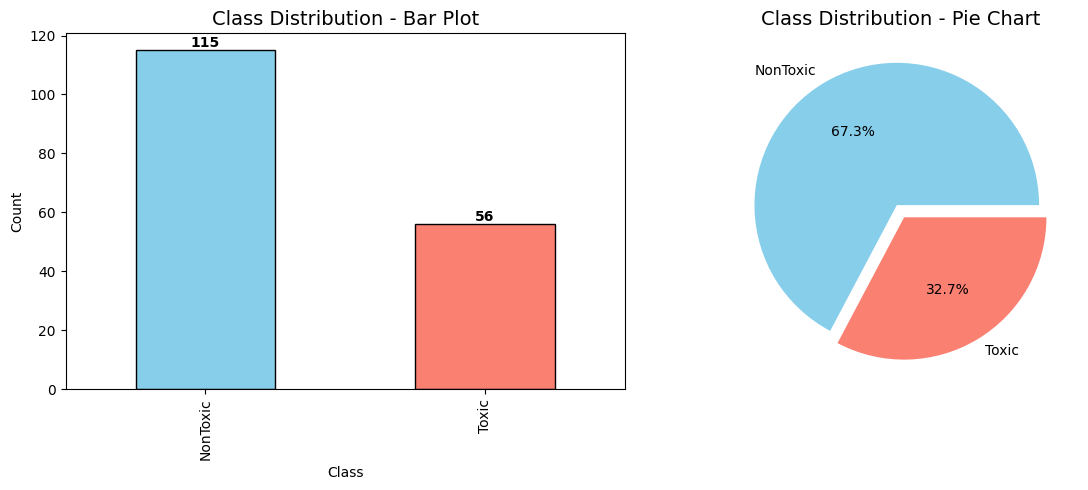

✅ Class distribution plot saved to outputs/class_distribution.png


In [8]:
# Analyze target variable
print("="*60)
print("STEP 2: CLASS DISTRIBUTION")
print("="*60)

class_counts = df['Class'].value_counts()
print(f"\n📊 Class Distribution:")
for cls, count in class_counts.items():
    percentage = (count/len(df)) * 100
    print(f"   {cls}: {count} samples ({percentage:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
class_counts.plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon'], edgecolor='black')
axes[0].set_title('Class Distribution - Bar Plot', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
class_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                  colors=['skyblue', 'salmon'], explode=[0.05, 0.05])
axes[1].set_title('Class Distribution - Pie Chart', fontsize=14)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('outputs/class_distribution.png')
plt.show()
print("✅ Class distribution plot saved to outputs/class_distribution.png")

In [9]:
# Check data quality
print("="*60)
print("STEP 3: DATA QUALITY CHECK")
print("="*60)

# Missing values
missing = df.isnull().sum().sum()
print(f"   Missing values: {missing}")

# Constant features
constant_features = [col for col in df.columns[:-1] if df[col].nunique() == 1]
print(f"   Constant features: {len(constant_features)}")

# Basic stats of first few features
print(f"\n📊 Basic statistics (first 5 features):")
print(df.iloc[:, :5].describe())

STEP 3: DATA QUALITY CHECK
   Missing values: 0
   Constant features: 0

📊 Basic statistics (first 5 features):
       python model.pyMATS3v    nHBint10      MATS3s      MATS3p  \
count             171.000000  171.000000  171.000000  171.000000   
mean               -0.031244    0.315789   -0.001001   -0.061501   
std                 0.063559    0.762918    0.063928    0.072891   
min                -0.311500    0.000000   -0.184600   -0.348500   
25%                -0.066700    0.000000   -0.036000   -0.099550   
50%                -0.032500    0.000000   -0.002000   -0.059400   
75%                 0.004850    0.000000    0.029000   -0.017100   
max                 0.141100    4.000000    0.218100    0.129000   

       nHBDon_Lipinski  
count       171.000000  
mean          0.994152  
std           1.108773  
min           0.000000  
25%           0.000000  
50%           1.000000  
75%           2.000000  
max           6.000000  


In [10]:
# Preprocess the data
print("="*60)
print("STEP 4: PREPROCESSING")
print("="*60)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f"✅ Target encoded: 0 = {le.classes_[0]}, 1 = {le.classes_[1]}")

# Remove constant features
if constant_features:
    X = X.drop(columns=constant_features)
    print(f"✅ Removed {len(constant_features)} constant features")

print(f"\n📊 Features remaining: {X.shape[1]}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"\n✅ Train set: {X_train.shape}")
print(f"✅ Test set: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)
print(f"✅ Features scaled (mean=0, std=1)")

STEP 4: PREPROCESSING
✅ Target encoded: 0 = NonToxic, 1 = Toxic

📊 Features remaining: 1203

✅ Train set: (136, 1203)
✅ Test set: (35, 1203)
✅ Features scaled (mean=0, std=1)


In [11]:
# Select best features
print("="*60)
print("STEP 5: FEATURE SELECTION")
print("="*60)

# Use ANOVA to select top 100 features
selector = SelectKBest(f_classif, k=100)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Get selected feature names
selected_features = X.columns[selector.get_support()].tolist()
print(f"✅ Selected {len(selected_features)} features")
print(f"\n📊 First 10 selected features:")
print(selected_features[:10])

STEP 5: FEATURE SELECTION
✅ Selected 100 features

📊 First 10 selected features:
['python model.pyMATS3v', 'MATS3e', 'minHBint2', 'minHBint4', 'VR3_Dt', 'ECCEN', 'MDEC-14', 'VR2_Dt', 'nT6Ring', 'EE_Dzp']


In [12]:
# Train the model
print("="*60)
print("STEP 6: MODEL TRAINING")
print("="*60)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
model.fit(X_train_selected, y_train)
print(f"✅ Model trained successfully!")

STEP 6: MODEL TRAINING
✅ Model trained successfully!


In [13]:
# Perform cross-validation
print("="*60)
print("STEP 7: CROSS-VALIDATION")
print("="*60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_selected, y_train, cv=cv, scoring='roc_auc')
print(f"\n📊 Cross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

STEP 7: CROSS-VALIDATION

📊 Cross-validation ROC-AUC: 0.5704 (+/- 0.0984)


In [14]:
# Evaluate on test set
print("="*60)
print("STEP 8: MODEL EVALUATION")
print("="*60)

y_pred = model.predict(X_test_selected)
y_pred_proba = model.predict_proba(X_test_selected)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"\n📊 Test Set Performance:")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   ROC-AUC: {auc_score:.4f}")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

STEP 8: MODEL EVALUATION

📊 Test Set Performance:
   Accuracy: 0.7143
   ROC-AUC: 0.5890

📊 Classification Report:
              precision    recall  f1-score   support

    NonToxic       0.72      0.96      0.82        24
       Toxic       0.67      0.18      0.29        11

    accuracy                           0.71        35
   macro avg       0.69      0.57      0.55        35
weighted avg       0.70      0.71      0.65        35



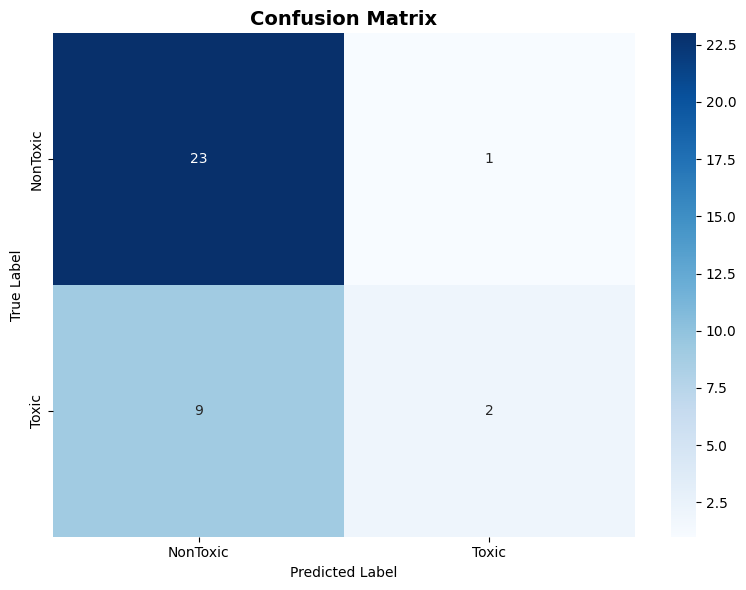

✅ Confusion matrix saved


In [15]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png')
plt.show()
print("✅ Confusion matrix saved")

STEP 9: FEATURE IMPORTANCE

📊 Top 10 Most Important Features:
              feature  importance
               SHaaCH    0.027007
            SpDiam_Dt    0.025139
              AATSC8s    0.019592
              AATSC8i    0.019301
              AATSC3v    0.019300
python model.pyMATS3v    0.019072
              SHother    0.018150
           SpMin4_Bhs    0.017731
               MATS5s    0.017409
               GATS7c    0.016952


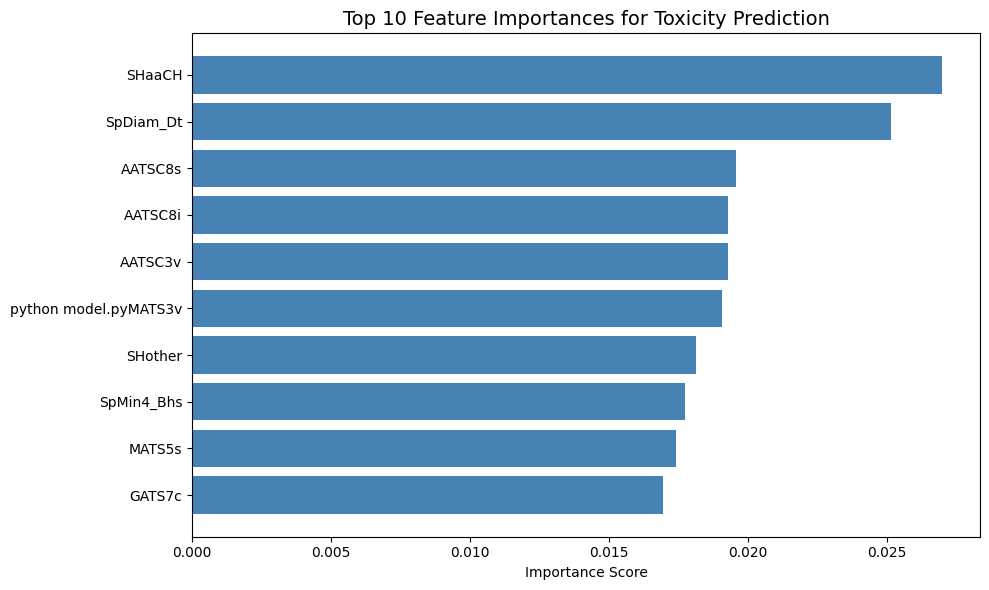

✅ Feature importances saved to outputs/feature_importances.csv


In [16]:
# Analyze feature importance
print("="*60)
print("STEP 9: FEATURE IMPORTANCE")
print("="*60)

importances = pd.DataFrame({
    'feature': selected_features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(importances.head(10).to_string(index=False))

# Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(range(10), importances.head(10)['importance'].values, color='steelblue')
plt.yticks(range(10), importances.head(10)['feature'].values)
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importances for Toxicity Prediction', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/top10_features.png')
plt.show()

# Save to CSV
importances.to_csv('outputs/feature_importances.csv', index=False)
print("✅ Feature importances saved to outputs/feature_importances.csv")

In [17]:
# Final summary
print("="*60)
print("STEP 10: ANALYSIS SUMMARY")
print("="*60)

print(f"""
{'='*60}
📋 ANALYSIS COMPLETE - SUMMARY
{'='*60}

📊 DATASET:
   • Total samples: {df.shape[0]}
   • Total features: {df.shape[1] - 1}
   • Class distribution: {class_counts.to_dict()}

🔧 PREPROCESSING:
   • Removed {len(constant_features)} constant features
   • Final features: {X.shape[1]}

🎯 FEATURE SELECTION:
   • Features selected: {len(selected_features)}
   • CV ROC-AUC: {cv_scores.mean():.4f}

🤖 MODEL PERFORMANCE:
   • Test Accuracy: {accuracy:.4f}
   • Test ROC-AUC: {auc_score:.4f}

🔬 TOP 5 FEATURES:
""")

for i, row in importances.head(5).iterrows():
    print(f"   {i+1}. {row['feature']}: {row['importance']:.4f}")

print(f"""
{'='*60}
✅ All results saved to 'outputs/' folder
{'='*60}
""")

STEP 10: ANALYSIS SUMMARY

📋 ANALYSIS COMPLETE - SUMMARY

📊 DATASET:
   • Total samples: 171
   • Total features: 1203
   • Class distribution: {'NonToxic': 115, 'Toxic': 56}

🔧 PREPROCESSING:
   • Removed 0 constant features
   • Final features: 1203

🎯 FEATURE SELECTION:
   • Features selected: 100
   • CV ROC-AUC: 0.5704

🤖 MODEL PERFORMANCE:
   • Test Accuracy: 0.7143
   • Test ROC-AUC: 0.5890

🔬 TOP 5 FEATURES:

   37. SHaaCH: 0.0270
   24. SpDiam_Dt: 0.0251
   45. AATSC8s: 0.0196
   49. AATSC8i: 0.0193
   14. AATSC3v: 0.0193

✅ All results saved to 'outputs/' folder



In [18]:
# Save results summary to text file
with open('outputs/results_summary.txt', 'w') as f:
    f.write("TOXICITY PREDICTION RESULTS\n")
    f.write("="*40 + "\n\n")
    f.write(f"Total samples: {df.shape[0]}\n")
    f.write(f"Total features: {df.shape[1]-1}\n")
    f.write(f"Class distribution: {class_counts.to_dict()}\n\n")
    f.write(f"Features selected: {len(selected_features)}\n")
    f.write(f"CV ROC-AUC: {cv_scores.mean():.4f}\n")
    f.write(f"Test Accuracy: {accuracy:.4f}\n")
    f.write(f"Test ROC-AUC: {auc_score:.4f}\n\n")
    f.write("Top 10 Features:\n")
    for i, row in importances.head(10).iterrows():
        f.write(f"   {row['feature']}: {row['importance']:.4f}\n")

print("✅ Results summary saved to outputs/results_summary.txt")
print("\n" + "="*60)
print("🎉 ANALYSIS COMPLETE!")
print("="*60)

✅ Results summary saved to outputs/results_summary.txt

🎉 ANALYSIS COMPLETE!
